## Distribution validations

### Imports

In [4]:
import pandas as pd
import great_expectations as gx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading Data

In [16]:
df = pd.read_csv('../../data/raw/diabetes_prediction_dataset.csv')
df.head(6)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0


## Check Null Values

In [12]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

## Identify Column Types

In [7]:
numerical_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(exclude='number').columns

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes'],
      dtype='str')
Categorical columns: Index(['gender', 'smoking_history'], dtype='str')


## Generate Profile

In [17]:
from scipy.stats import skew, kurtosis
profile = pd.DataFrame({
    'Column': numerical_cols,
    'Min': df[numerical_cols].min().values,
    'Max': df[numerical_cols].max().values,
    'Mean': df[numerical_cols].mean().values,
    'Median': df[numerical_cols].median().values,
    'Std': df[numerical_cols].std().values,
    'Skewness': [skew(df[col].dropna()) for col in numerical_cols],
    'Kurtosis': [kurtosis(df[col].dropna()) for col in numerical_cols],
    'Unique': df[numerical_cols].nunique().values
})
profile.head(6)

,Column,Min,Max,Mean,Median,Std,Skewness,Kurtosis,Unique
0,age,0.08,80.00,41.885856,43.00,22.516840,-0.051978,-1.003845,102
1,hypertension,0.00,1.00,0.074850,0.00,0.263150,3.231247,8.440959,2
2,heart_disease,0.00,1.00,0.039420,0.00,0.194593,4.733801,20.408871,2
3,bmi,10.01,95.69,27.320767,27.32,6.636783,1.043820,3.520536,4247
4,HbA1c_level,3.50,9.00,5.527507,5.80,1.070672,-0.066853,0.215322,18
5,blood_glucose_level,80.00,300.00,138.058060,140.00,40.708136,0.821643,1.737477,18


## Visual Distribution

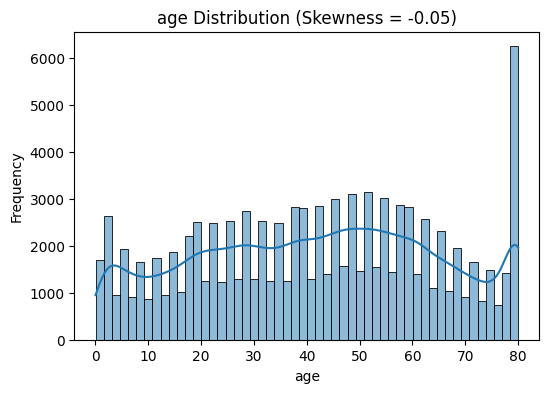

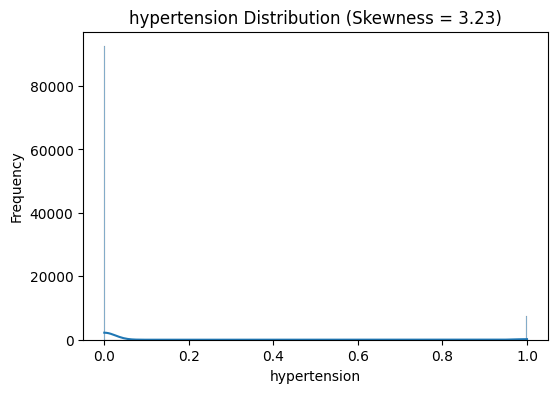

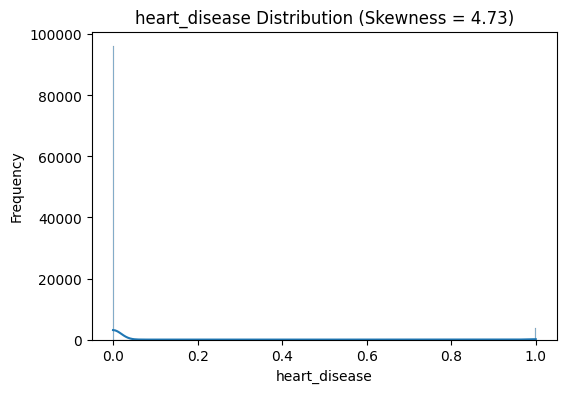

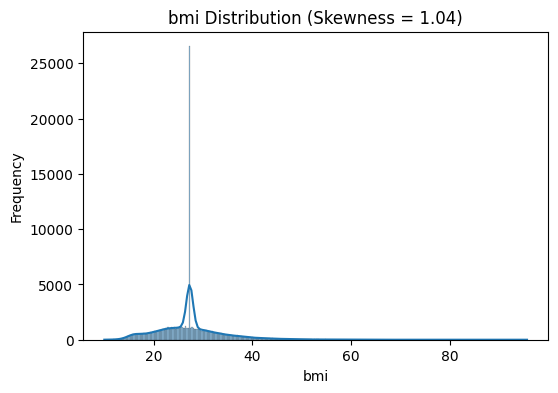

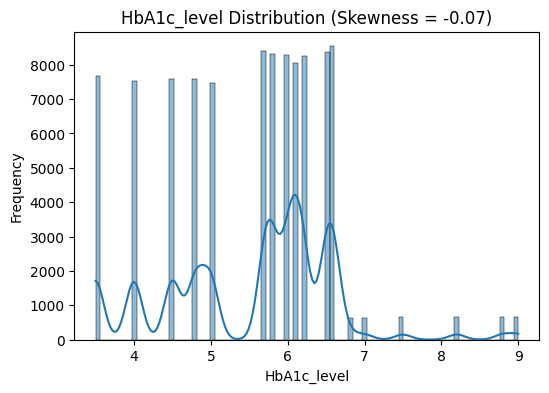

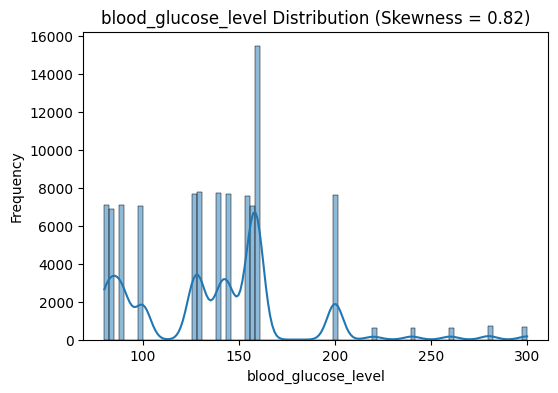

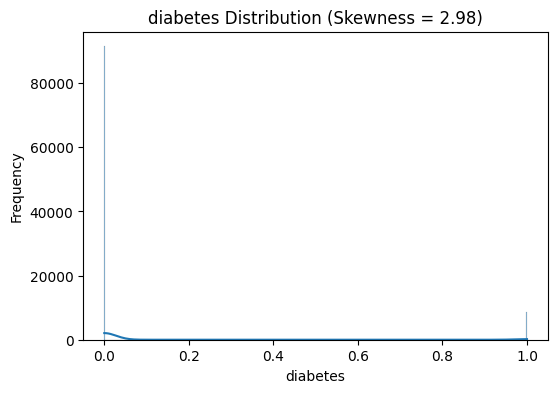

In [14]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution (Skewness = {df[col].skew():.2f})")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()